# Projeto Final — Análise Exploratória de Dados (Olist)

## 1. Apresentação da Base e Perguntas de Negócio
### Origem dos Dados
Os dados foram extraídos do dataset público do **Olist** no Kaggle, cobrindo o e-commerce brasileiro.

### Perguntas de Negócio
1. **Prazos e Frete:** Qual a relação entre o custo do frete e o tempo real de entrega entre os diferentes estados?
2. **Meios de Pagamento e Ticket:** Como o valor médio do pedido varia em função do tipo de pagamento e do parcelamento?
3. **Outliers de Frete:** Quais estados apresentam os maiores outliers de valor de frete em relação ao preço das mercadorias?
4. **Recorrência:** Clientes recorrentes possuem comportamento de compra diferente dos clientes pontuais?

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Leitura das bases de dados (existentes + novas)
df_customers = pd.read_csv('../dados/olist_customers_dataset.csv')
df_orders = pd.read_csv('../dados/olist_orders_dataset.csv')
df_items = pd.read_csv('../dados/olist_order_items_dataset.csv')
df_payments = pd.read_csv('../dados/olist_order_payments_dataset.csv')

# Novas bases
df_reviews = pd.read_csv('../dados/olist_order_reviews_dataset.csv')
df_products = pd.read_csv('../dados/olist_products_dataset.csv')
df_categories = pd.read_csv('../dados/product_category_name_translation.csv')

print("Todas as 7 bases foram carregadas com sucesso!")

Todas as 7 bases foram carregadas com sucesso!


Realizamos a junção das 7 bases para criar o DataFrame consolidado da análise.

In [11]:
# 1. Mapeia o nome da categoria em inglês
df_products = df_products.merge(df_categories, on='product_category_name', how='left')

# 2. Unificação de todas as tabelas no DataFrame principal
df = df_orders.merge(df_customers, on='customer_id', how='inner') \
              .merge(df_items, on='order_id', how='inner') \
              .merge(df_payments, on='order_id', how='inner') \
              .merge(df_products, on='product_id', how='left') \
              .merge(df_reviews, on='order_id', how='left')

print(f"Shape do Dataset Consolidado: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head(3)

Shape do Dataset Consolidado: 118307 linhas x 37 colunas


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48


## 2. Diagnóstico de Qualidade dos Dados
Dimensões, tipos, uso de memória

#### 2.1 Dimensões e Tipos

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118307 entries, 0 to 118306
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118307 non-null  str    
 1   customer_id                    118307 non-null  str    
 2   order_status                   118307 non-null  str    
 3   order_purchase_timestamp       118307 non-null  str    
 4   order_approved_at              118292 non-null  str    
 5   order_delivered_carrier_date   117053 non-null  str    
 6   order_delivered_customer_date  115719 non-null  str    
 7   order_estimated_delivery_date  118307 non-null  str    
 8   customer_unique_id             118307 non-null  str    
 9   customer_zip_code_prefix       118307 non-null  int64  
 10  customer_city                  118307 non-null  str    
 11  customer_state                 118307 non-null  str    
 12  order_item_id                  118307 non

Faltantes por coluna (quantidade e percentual)

In [20]:
# Verificação de Faltantes
nulos = pd.DataFrame({
    'Total_Nulos': df.isnull().sum(),
    'Percentual_%': (df.isnull().mean() * 100).round(2)
})
print(nulos[nulos['Total_Nulos'] > 0].sort_values(by='Total_Nulos', ascending=False))

                               Total_Nulos  Percentual_%
review_comment_title                104415         88.26
review_comment_message               68628         58.01
order_delivered_customer_date         2588          2.19
product_category_name_english         1734          1.47
product_category_name                 1709          1.44
product_name_lenght                   1709          1.44
product_description_lenght            1709          1.44
product_photos_qty                    1709          1.44
order_delivered_carrier_date          1254          1.06
review_answer_timestamp                978          0.83
review_score                           978          0.83
review_creation_date                   978          0.83
review_id                              978          0.83
product_height_cm                       20          0.02
product_width_cm                        20          0.02
product_length_cm                       20          0.02
product_weight_g               

Duplicados, categorias inconsistentes, valores inválidos

In [21]:
# Verificação de Duplicados
print(f"\nLinhas duplicadas no dataset consolidado: {df.duplicated().sum()}")


Linhas duplicadas no dataset consolidado: 0


### 2.2 Identificação de Outliers

#### Método IQR

In [22]:
# Seleciona apenas colunas numéricas
colunas_numericas = df.select_dtypes(include="number").columns

# Opcional: remova identificadores ou códigos que não devem ser analisados
# colunas_numericas = colunas_numericas.drop(["order_item_id"])

outliers = pd.DataFrame(False, index=df.index, columns=colunas_numericas)
limites = {}

for coluna in colunas_numericas:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    limites[coluna] = (limite_inferior, limite_superior)

    outliers[coluna] = (
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    )

# Quantidade de outliers por coluna
quantidade_outliers = outliers.sum().sort_values(ascending=False)
print(quantidade_outliers[quantidade_outliers > 0])

review_score                  18939
product_weight_g              16696
order_item_id                 14663
freight_value                 12740
payment_value                  9549
price                          8867
product_height_cm              8101
payment_installments           8085
product_description_lenght     7382
payment_sequential             5085
product_length_cm              3822
product_photos_qty             3205
product_width_cm               2754
product_name_lenght             804
dtype: int64


In [23]:
df_outliers = df[outliers.any(axis=1)]

print(df_outliers.shape)
display(df_outliers.head())

(63077, 37)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,...,65.0,10.0,65.0,auto,89b738e70a1ce346db29a20fb2910161,4.0,NaN,NaN,2017-07-27 00:00:00,2017-07-27 22:48:30
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,36edbb3fb164b1f16485364b6fb04c73,98900,...,35.0,35.0,15.0,NaN,e07549ef5311abcc92ba1784b093fb56,2.0,NaN,fiquei triste por n ter me atendido.,2017-05-13 00:00:00,2017-05-13 20:25:42
10,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,39382392765b6dc74812866ee5ee92a7,99655,...,35.0,35.0,15.0,furniture_decor,fc4af8aea8ec3f1a3cd181d3d0cadbd5,1.0,NaN,NaN,2017-02-03 00:00:00,2017-02-05 01:58:35


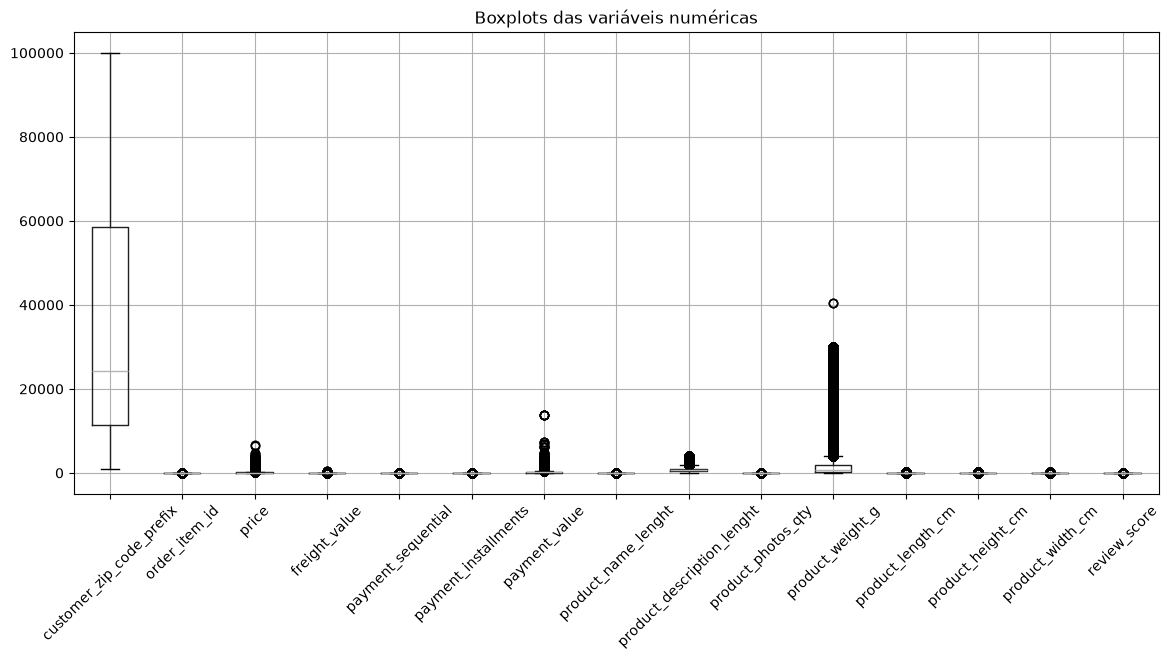

In [17]:
df[colunas_numericas].boxplot(figsize=(14, 6), rot=45)
plt.title("Boxplots das variáveis numéricas")
plt.show()

#### Método Z-Score

In [24]:
# Seleciona apenas colunas numéricas
colunas_numericas = df.select_dtypes(include="number").columns

# Opcional: remova identificadores ou códigos que não devem ser analisados
# colunas_numericas = colunas_numericas.drop(["order_item_id"])

# Calcula o z-score de cada valor em relação à sua coluna
media = df[colunas_numericas].mean()
desvio_padrao = df[colunas_numericas].std()
z_scores = (df[colunas_numericas] - media) / desvio_padrao

# Considera outlier todo valor com z-score absoluto maior que 3
limite_z = 3
outliers_z = z_scores.abs() > limite_z

# Quantidade de outliers por coluna
quantidade_outliers_z = outliers_z.sum().sort_values(ascending=False)
print(quantidade_outliers_z[quantidade_outliers_z > 0])

# Linhas que possuem pelo menos um outlier
df_outliers_z = df[outliers_z.any(axis=1)]
print(f"\\nLinhas com pelo menos um outlier: {df_outliers_z.shape[0]}")
display(df_outliers_z.head())

product_weight_g              3083
product_description_lenght    2871
product_height_cm             2864
product_length_cm             2336
freight_value                 2162
price                         2088
order_item_id                 1952
payment_value                 1840
product_width_cm              1825
product_photos_qty            1645
payment_sequential            1045
product_name_lenght            579
payment_installments           409
dtype: int64
\nLinhas com pelo menos um outlier: 17213


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,80bb27c7c16e8f973207a5086ab329e2,86320,...,65.0,10.0,65.0,auto,89b738e70a1ce346db29a20fb2910161,4.0,NaN,NaN,2017-07-27 00:00:00,2017-07-27 22:48:30
20,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,delivered,2018-01-02 19:00:43,2018-01-02 19:09:04,2018-01-03 18:19:09,2018-01-20 01:38:59,2018-02-06 00:00:00,6e26bbeaa107ec34112c64e1ee31c0f5,21381,...,100.0,25.0,50.0,construction_tools_construction,NaN,NaN,NaN,NaN,NaN,NaN
29,95266dbfb7e20354baba07964dac78d5,a166da34890074091a942054b36e4265,delivered,2018-01-08 07:55:29,2018-01-08 08:07:31,2018-01-24 23:16:37,2018-01-26 17:32:38,2018-02-21 00:00:00,451e48381edab7f1f6dbfa6d728616ff,89070,...,77.0,20.0,53.0,baby,1d507207ffd8c75b785304b33e2f6c59,4.0,NaN,NaN,2018-01-27 00:00:00,2018-01-28 11:42:31
37,f70a0aff17df5a6cdd9a7196128bd354,456dc10730fbdba34615447ea195d643,delivered,2017-08-10 11:58:33,2017-08-12 02:45:24,2017-08-17 15:35:07,2017-08-18 14:28:02,2017-08-23 00:00:00,1974875b4a1d2e2ee6d586e3ba4d7602,5634,...,44.0,70.0,32.0,baby,2f111691fc93df88fc3aa8c2deac61ce,2.0,NaN,O produto veio faltando a base para auto e com...,2017-08-19 00:00:00,2017-08-19 23:46:02
42,8563039e855156e48fccee4d611a3196,5f16605299d698660e0606f7eae2d2f9,delivered,2018-02-17 15:59:46,2018-02-17 16:15:34,2018-02-20 23:03:56,2018-03-20 00:59:25,2018-03-20 00:00:00,92fd8aa5948e20c43a014c44c025c5e1,77480,...,90.0,20.0,20.0,garden_tools,f121467a10eee0929f364c7d62abc9b5,5.0,NaN,há muito tempo efetuo compras atraves desta lo...,2018-03-20 00:00:00,2018-03-23 22:56:05


Próximo passo: Analisar a distribuição de cada variável quantitativa para determinar o tipo (normal ou assimétrica)

In [25]:
# 2.3 Análise de Distribuição das Variáveis Quantitativas

# Seleção das colunas numéricas (excluindo IDs sequenciais/códigos se houver)
colunas_numericas = df.select_dtypes(include=["number"]).columns
if 'order_item_id' in colunas_numericas:
    colunas_numericas = colunas_numericas.drop(['order_item_id'])

# Cálculo das métricas de Assimetria (Skewness) e Curtose (Kurtosis)
dados_distribuicao = []

for col in colunas_numericas:
    skew = df[col].skew()
    kurt = df[col].kurt()
    
    # Classificação baseada no Skewness
    if abs(skew) < 0.5:
        tipo_distribuicao = "Aproximadamente Normal"
    elif skew >= 0.5:
        tipo_distribuicao = "Assimétrica à Direita (Cauda Longa)"
    else:
        tipo_distribuicao = "Assimétrica à Esquerda"
        
    dados_distribuicao.append({
        'Variável': col,
        'Média': df[col].mean(),
        'Mediana': df[col].median(),
        'Desvio Padrão': df[col].std(),
        'Skewness (Assimetria)': round(skew, 2),
        'Kurtosis': round(kurt, 2),
        'Classificação': tipo_distribuicao
    })

df_distribuicao = pd.DataFrame(dados_distribuicao)
display(df_distribuicao)

,Variável,Média,Mediana,Desvio Padrão,Skewness (Assimetria),Kurtosis,Classificação
0,customer_zip_code_prefix,35051.177276,24310.00,29824.786247,0.78,-0.78,Assimétrica à Direita (Cauda Longa)
1,price,120.648522,74.90,184.111631,7.89,119.15,Assimétrica à Direita (Cauda Longa)
2,freight_value,20.032823,16.28,15.836814,5.54,57.64,Assimétrica à Direita (Cauda Longa)
3,payment_sequential,1.094069,1.00,0.728579,15.90,346.91,Assimétrica à Direita (Cauda Longa)
4,payment_installments,2.943317,2.00,2.777877,1.62,2.51,Assimétrica à Direita (Cauda Longa)
5,payment_value,172.575102,108.20,267.110727,14.09,508.21,Assimétrica à Direita (Cauda Longa)
6,product_name_lenght,48.767878,52.00,10.033390,-0.90,0.15,Assimétrica à Esquerda
7,product_description_lenght,785.961389,600.00,652.591284,2.01,4.93,Assimétrica à Direita (Cauda Longa)
8,product_photos_qty,2.205192,1.00,1.717463,1.91,4.82,Assimétrica à Direita (Cauda Longa)
9,product_weight_g,2112.278949,700.00,3786.738987,3.58,16.02,Assimétrica à Direita (Cauda Longa)


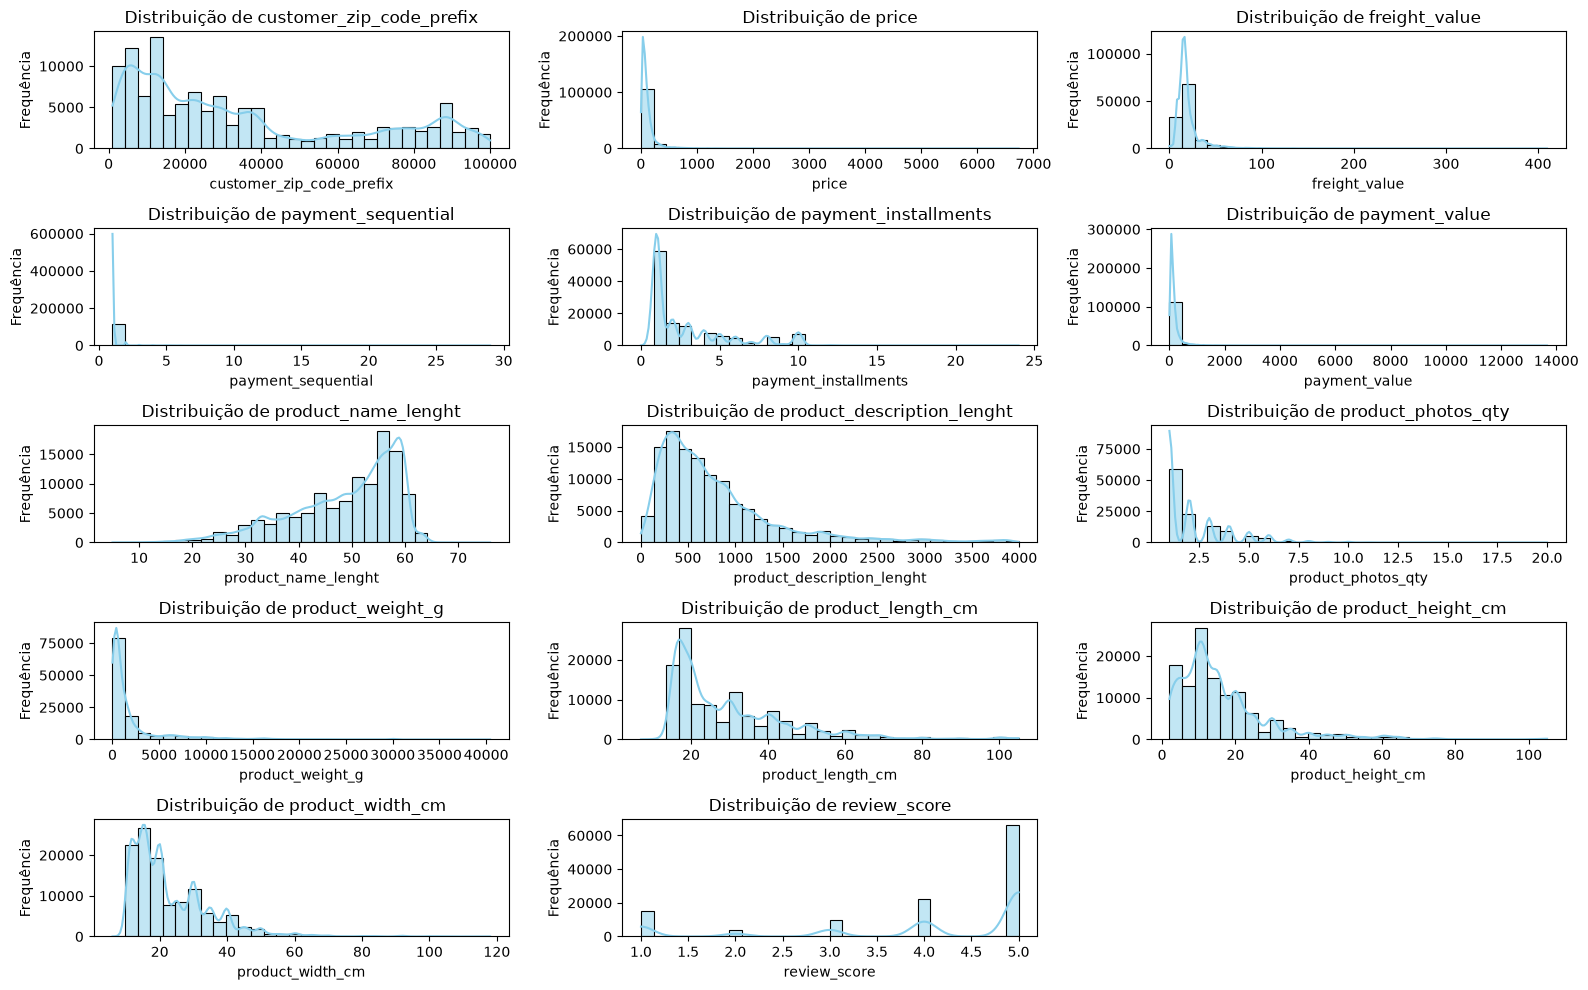

In [26]:
# Plot dos histogramas com estimativa de densidade de kernel (KDE)
plt.figure(figsize=(16, 10))
num_cols = len(colunas_numericas)
cols_per_row = 3
rows = (num_cols + cols_per_row - 1) // cols_per_row

for i, col in enumerate(colunas_numericas, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

## 3 Limpeza e transformação

In [27]:
# 1. Lista de todas as colunas com tipos de dados e contagem de não-nulos
print("--- INFORMAÇÕES DO DATASET CONSOLIDADO ---")
df.info(verbose=True, show_counts=True)

--- INFORMAÇÕES DO DATASET CONSOLIDADO ---
<class 'pandas.DataFrame'>
RangeIndex: 118307 entries, 0 to 118306
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118307 non-null  str    
 1   customer_id                    118307 non-null  str    
 2   order_status                   118307 non-null  str    
 3   order_purchase_timestamp       118307 non-null  str    
 4   order_approved_at              118292 non-null  str    
 5   order_delivered_carrier_date   117053 non-null  str    
 6   order_delivered_customer_date  115719 non-null  str    
 7   order_estimated_delivery_date  118307 non-null  str    
 8   customer_unique_id             118307 non-null  str    
 9   customer_zip_code_prefix       118307 non-null  int64  
 10  customer_city                  118307 non-null  str    
 11  customer_state                 118307 non-null  str    
 12

In [28]:
# 2. Amostra de 5 linhas com todas as colunas visíveis
pd.set_option('display.max_columns', None)
df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1,credit_card,1,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3,voucher,1,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2,voucher,1,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1,boleto,1,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1,credit_card,3,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


In [29]:
# 1. Seleção das colunas essenciais para as Perguntas de Negócio
colunas_essenciais = [
    'order_id',
    'customer_unique_id',
    'customer_state',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'price',
    'freight_value',
    'payment_type',
    'payment_installments',
    'payment_value',
    'product_category_name',
    'product_category_name_english',
    'review_score'
]

# Filtra o DataFrame principal para manter somente as colunas selecionadas
df = df[colunas_essenciais].copy()

# 2. Conversão das colunas de data para datetime
colunas_datas = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in colunas_datas:
    df[col] = pd.to_datetime(df[col])

# 3. Criação de Métricas de Entrega
# Tempo real de entrega em dias
df['tempo_entrega_dias'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# Diferença do prazo estimado em dias (positivo = atraso / negativo = adiantado)
df['dias_diferenca_estimada'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.total_seconds() / (24 * 3600)

# Indicador de entrega com atraso
df['entregue_com_atraso'] = df['dias_diferenca_estimada'] > 0

# 4. Preenchimento simples de nulos em categorias
df['product_category_name'] = df['product_category_name'].fillna('outro')
df['product_category_name_english'] = df['product_category_name_english'].fillna('other')

print("--- DATASET REDUZIDO E LIMPO ---")
print(f"Estrutura final: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head(3)

--- DATASET REDUZIDO E LIMPO ---
Estrutura final: 118307 linhas x 17 colunas


,order_id,customer_unique_id,customer_state,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,payment_type,payment_installments,payment_value,product_category_name,product_category_name_english,review_score,tempo_entrega_dias,dias_diferenca_estimada,entregue_com_atraso
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,29.99,8.72,credit_card,1,18.12,utilidades_domesticas,housewares,4.0,8.436574,-7.107488,False
1,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,29.99,8.72,voucher,1,2.00,utilidades_domesticas,housewares,4.0,8.436574,-7.107488,False
2,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,29.99,8.72,voucher,1,18.59,utilidades_domesticas,housewares,4.0,8.436574,-7.107488,False


## 4 Análise exploratória

## 5 Conclusões